# Read CSV data into a pandas dataframe

本笔记本中使用的数据来自Kaggle的4.8万部电影数据集，除了原始评论文本外，还包含大量元数据。

通常需要进行数据清洗，例如将空字符串替换为""，或将异常或为空的字段替换为中位数值。下面我将直接删除包含空值的行。

In [1]:
import sys,os,time,pprint
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.append("..")
import milvus_utilities as _utils

In [2]:
CUSTOM_CACHE = r'F:\Teewon\Milvue\models'
os.environ['HF_HOME'] = CUSTOM_CACHE
os.environ['HF_HUB_CACHE'] = os.path.join(CUSTOM_CACHE, 'hub')
os.environ['TRANSFORMERS_CACHE'] = os.path.join(CUSTOM_CACHE, 'transformers')

Read [CSV data](https://www.kaggle.com/datasets/yashgupta24/48000-movies-dataset)

In [3]:
df=pd.read_csv("data/original_data.csv")

# 将“Name”、“Keywords”和“Description”拼接成“text”列
df['text']=df['Name']+' '+df['Description']+' '+df['ReviewBody']

# drop rows without any text
print(df.shape[0])
df=df.dropna(subset=['text'])
print(df.shape[0])

# 将包含逗号的字符串格式的类型转换为字符串列表
df['Genres']=df['Genres'].str.split(',')
df['Genres']=df['Genres'].apply(lambda d:d if isinstance(d,list) else [""])

# Convert actors from string with commas in it to list of strings
df['Actors']=df['Actors'].str.split(',')
df['Actors']=df['Actors'].apply(lambda d:d if isinstance(d,list) else [""])

# Convert keywords from string with commas in it to list of strings
df['Keywords']=df['Keywords'].str.split(',')
df['Keywords']=df['Keywords'].apply(lambda d:d if isinstance(d,list) else [""])

# Extract out just the year from the date
def extract_year(movie_date):
    try:
        return int(movie_date.split('-')[0])
    except Exception:
        return -1

df['MovieYear']=df.DatePublished.apply(extract_year)

# Convert 'Rating' to float
df['RatingValue']=pd.to_numeric(df['RatingValue'], errors='coerce') # 如果某个值无法转换为数字（比如是字符串 "Not Rated"、空字符串 ""、或者字母 "N/A"），则不会报错，而是将其变为 NaN
df['RatingValue']=df['RatingValue'].fillna(-1).astype('float32')

# Drop extra rating columns
df.drop(columns=['RatingCount','BestRating','WorstRating','ReviewAurthor','ReviewAurthor','ReviewDate','ReviewBody','Description','duration','DatePublished'], inplace=True)

#　Inspect text
print(f"Example text length {len(df.text[0])}")
pprint.pprint(f"Example text: {df.text[0]}")

# Shortcut the data for testing.
df=df.tail(250).copy()

print(df.dtypes)
display(df.head(2))

48513
45036
Example text length 6556
('Example text: Sallie Gardner at a Gallop Sallie Gardner at a Gallop is a '
 'short starring Gilbert Domm and Sallie Gardner. The clip shows a jockey, '
 'Domm, riding a horse, Sally Gardner. The clip is not filmed but instead '
 'consists of 24 individual photographs shot in rapid... Sometimes ascribed as '
 '"The Father of the Motion Picture", Eadweard Muybridge undeniably '
 'accomplished exploiting and sometimes introducing a means of instantaneous '
 'and serial images to analyze and synthesize animal locomotion. In part, the '
 "reasons for and the claims made of his work support Virgilio Tosi's thesis "
 'that cinema was invented out of the needs of scientific research. '
 "Conversely, they're informed by Muybridge's background as an artistic "
 'location photographer and, as Phillip Prodger suggests, in book sales and '
 'more useful to art than to science, as Marta Braun has demonstrated (see '
 'sources at bottom). Additionally, Muybridge

,id,url,Name,PosterLink,Genres,Actors,Director,Keywords,RatingValue,text,MovieYear
48232,48232,https://www.imdb.com/title/tt7044010/,Rory Scovel Tries Stand-Up for the First Time,https://m.media-amazon.com/images/M/MV5BZWUxM2...,"[Documentary, Comedy]","[Rory Scovel, Jack White, Ben Swank, Ben Kronb...",Scott Moran,"[stand up special, stand up comedy, tv special]",6.7,Rory Scovel Tries Stand-Up for the First Time ...,2017
48233,48233,https://www.imdb.com/title/tt7048622/,L'insulte,https://m.media-amazon.com/images/M/MV5BZTI1NG...,"[Crime, Drama, Thriller]","[Adel Karam, Kamel El Basha, Camille Salameh, ...",Ziad Doueiri,"[court case, courtroom drama, prejudice, insul...",7.7,L'insulte L'insulte is a movie starring Adel K...,2017


# Connect using Milvus Lite

Milvus Lite 是一个轻量级的 Python 服务器，可本地运行。它非常适合在笔记本电脑、Jupyter 笔记本或 Colab 上快速入门 Milvus。

⛔️ 请注意，Milvus Lite 仅用于演示，不适用于生产环境的工作负载。

## STEP 1. CONNECT TO MILVUS STANDALONE DOCKER

In [4]:
import pymilvus
print(f"pymilvus: {pymilvus.__version__}")

from pymilvus import MilvusClient
mc = MilvusClient("../milvus_demo.db")

pymilvus: 2.6.17


## Optional - Connect using Milvus standalone Docker

本节使用 Docker 容器运行 Milvus 独立版。

> ⛔️ 请确保通过 pip 安装正确版本的 pymilvus 和 server yml 文件。版本（主版本和次版本）必须完全匹配。

1. 安装 Docker
2. 启动您的 Docker Desktop
3. 下载最新的 docker-compose.yml 文件（或运行 wget 命令，将 version 替换为您使用的版本）
> wget https://github.com/milvus-io/milvus/releases/download/v2.4.0-rc.1/milvus-standalone-docker-compose.yml -O docker-compose.yml

4. 在终端中：
- 进入保存 .yml 文件的目录（通常与本笔记本在同一目录）
- docker compose up -d
- 验证容器是否正在运行（可在终端或 Docker Desktop 中查看）

5. 从代码中（参见下方笔记本代码）：
- 导入 milvus
- 连接到本地 Milvus 服务器

In [5]:
# import pymilvus
# from pymilvus import MilvusClient,utility,connections
#
# !docker compose up -d
#
# connection=connections.connect(
#     alias='default',
#     host='localhost',
#     port='19530',
# )
#
# print(f"Milvus server: {utility.get_server_version()}")

# Load the Embedding Model checkpoint and use it to create vector embeddings

嵌入模型：我们将使用 HuggingFace 上提供的开源句子转换模型来编码文档文本。我们会从 HuggingFace 下载该模型，并在本地运行。

💡提示：选择句子转换模型的好方法是查看 [MTEB 领先榜单](https://huggingface.co/spaces/mteb/leaderboard)。按“检索平均”列降序排列，选择表现最佳的小型模型。

以下两个模型参数值得注意：

1. EMBEDDING_DIM 指的是嵌入向量的维度或长度。在此情况下，输入文本中每个标记生成的嵌入向量长度相同，均为 1024。这种嵌入大小通常与基于 BERT 的模型相关，其嵌入用于下游任务，如分类、问答或文本生成。

2. MAX_SEQ_LENGTH 是编码器模型可处理的最大上下文长度。在此情况下，如果输入序列超过 512 个标记，所有过长的部分将被（静默地！）截断。因此，需要采用分块策略，将输入文本分割成适合模型输入长度的块。

## STEP 2. DOWNLOAD AN OPEN SOURCE EMBEDDING MODEL

In [6]:
import torch
from sentence_transformers import SentenceTransformer

# Initialize torch settings
torch.backends.cudnn.deterministic=True
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the model from huggingface model hub
model_name="BAAI/bge-large-en-v1.5"
encoder=SentenceTransformer(model_name,device=DEVICE)

# Get the model parameters and save for later
EMBEDDING_DIM=encoder.get_embedding_dimension()
MAX_SEQ_LENGTH_IN_TOKEN=encoder.get_max_seq_length()

# Assume tokens are 3 characters long
# MAX_SEQ_LENGTH=MAX_SEQ_LENGTH_IN_TOKEN*3
# EOS_TOKEN_LENGTH=1*3

# Use 512 sequence length
MAX_SEQ_LENGTH=MAX_SEQ_LENGTH_IN_TOKEN
EOS_TOEKN_LENGTH=1

# Inspect model parameters
print(f"model name: {model_name}")
print(f"EMBEDDING_DIM: {EMBEDDING_DIM}")
print(f"MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model name: BAAI/bge-large-en-v1.5
EMBEDDING_DIM: 1024
MAX_SEQ_LENGTH: 512


# Create a Milvus collection
在 Milvus 中，你可以将集合类比为 SQL 数据库中的“表”。该集合将包含以下内容：

- **模型架构**（或无架构的 Milvus 客户端）

    💡 你需要从嵌入模型中获取向量的 EMBEDDING_DIM 参数。常见取值如下：
    - sbert 嵌入模型：1024
    - ada-002 OpenAI 嵌入模型：1536

- **向量索引**，用于高效向量搜索
- **向量距离度量**，用于计算最近邻向量
- **一致性级别**：Milvus 支持事务一致性，但根据 CAP 定理，必须牺牲一定的延迟。💡 由于电影评论搜索并非关键任务，因此`eventually`在此处是可接受的。

# Add a Vector Index

向量索引用于确定在用户提交查询时，查找数据中与该查询最接近的向量所采用的向量搜索算法。

大多数向量索引根据数据库的使用场景（插入向量或搜索向量）而采用不同的参数组合：

- **插入向量**（创建模式）
- **搜索向量**（搜索模式）

请向下滚动文档页面，查看 Milvus 提供的不同向量索引列表。例如：

- FLAT — 确定性穷尽搜索
- IVF_FLAT 或 IVF_SQ8 — 哈希索引（随机近似搜索）
- HNSW — 图形索引（随机近似搜索）
- AUTOINDEX — 根据 OSS 与 Zilliz 云、GPU 类型及数据规模自动确定

除了搜索算法外，我们还需要指定**距离度量**，即定义向量空间中“接近”的标准。在下方单元格中选择了 `HNSW` 搜索索引。其可用的距离度量包括：

- L2 — L2 范数
- IP — 点积
- COSINE — 角度距离

💡 大多数应用场景更适合使用归一化嵌入（normalized embeddings），此时 L2 不适用（每个向量长度为1），IP 和 COSINE 相等。仅当您计划保持嵌入未归一化时，才应选择 L2。

## STEP 3. CREATE A NO-SCHEMA MILVUS COLLECTION AND DEFINE THE DATABASE INDEX

In [7]:
# Create a collection
COLLECTION_NAME="IMDB_metadata"

# Milvus Lite uses the MilvusClient object
if mc.has_collection(COLLECTION_NAME):
    mc.drop_collection(COLLECTION_NAME)
    print(f"Successfully dropped collection {COLLECTION_NAME}")

# Create a collection woth flexible schema and AUTOINDEX
mc.create_collection(
    COLLECTION_NAME,
    EMBEDDING_DIM,
    consistency_level="Eventually",
    auto_id=True,
    overwrite=True,
)
print(f"Successfully created collection {COLLECTION_NAME}")

Successfully dropped collection IMDB_metadata
Successfully created collection IMDB_metadata


# Simple Chunking

在嵌入之前，需要先确定您的分块策略、分块大小和分块重叠度。本节采用以下设置：

- **策略** = 简单的固定分块长度
- **分块大小** = 使用嵌入模型参数 MAX_SEQ_LENGTH
- **重叠度** = 一般建议 10%-15%
- **函数** = Langchain 的`RecursiveCharacterTextSplitter`，用于递归拆分长评论

## STEP 4. PREPARE DATA: CHUNK AND EMBED

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def recursive_splitter_wrapper(text,chunk_size):
    # Default chunk overlap is 10% chunk size
    chunk_overlap=np.round(chunk_size*0.1,0)

    # Use langchain's convenient recursive chunking method
    text_splitter=RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
    )
    chunks=text_splitter.split_text(text)

    # Repalce special characters with spaces
    chunks=[text.replace("<br /><br />"," ")for text in chunks]

    return chunks

# Use recursive splitter to chunk text
def imdb_chunk_text(batch_size,df,chunk_size):
    batch=df.head(batch_size).copy()
    print(f"chunk size: {chunk_size}")
    print(f"original shape: {batch.shape}")

    start_time=time.time()
    # 1. Chunk the text review into chunk size
    batch['chunk']=batch['text'].apply(recursive_splitter_wrapper,chunk_size=chunk_size)
    # Explode the 'chunk' column to create new rows for each chunk
    batch=batch.explode('chunk',ignore_index=True)
    print(f"new shape: {batch.shape}")

    # 2. Add embeddings as new column in df
    embeddings=torch.tensor(encoder.encode(batch['chunk'].tolist()))
    # Normalize the embeddings
    norm=np.linalg.norm(embeddings,axis=1, keepdims=True)
    embeddings=np.asarray(embeddings/norm)

    # 3. Convert embeddings to list of `numpy.ndarray` ,each containing `numpy.float32` numbers
    converted_values=list(map(np.float32,embeddings))
    batch['vector']=converted_values

    end_time=time.time()
    print(f"Chunking + embeddings time for {batch_size} docs: {end_time-start_time} sec")

    # Inspect the batch of data
    assert len(batch.chunk[0])<=MAX_SEQ_LENGTH-1
    assert len(batch.vector[0])==EMBEDDING_DIM
    print(f"type embeddings: {type(batch.vector)} of {type(batch.vector[0])}")
    print(f"of numbers: {type(batch.vector[0][0])}")

    return batch

In [9]:
# Chunk and Embed Text Data

# Use the embedding model parameters.
# chunk_size = MAX_SEQ_LENGTH - HF_EOS_TOKEN_LENGTH
chunk_size=512
chunk_overlap=np.round(chunk_size*0.1,0)

# Chunk a batch of data from pandas DataFrame and inspect it
BATCH_SIZE=800
batch=imdb_chunk_text(BATCH_SIZE,df,chunk_size)
display(batch.head(2))

# Drop the original text column, keep the new 'chunk' column
batch.drop(columns=['text'], inplace=True)

chunk size: 512
original shape: (250, 11)
new shape: (807, 12)
Chunking + embeddings time for 800 docs: 47.23421764373779 sec
type embeddings: <class 'pandas.Series'> of <class 'numpy.ndarray'>
of numbers: <class 'numpy.float32'>


C:\Users\Administrator\AppData\Local\Temp\ipykernel_29012\863435763.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  embeddings=np.asarray(embeddings/norm)


,id,url,Name,PosterLink,Genres,Actors,Director,Keywords,RatingValue,text,MovieYear,chunk,vector
0,48232,https://www.imdb.com/title/tt7044010/,Rory Scovel Tries Stand-Up for the First Time,https://m.media-amazon.com/images/M/MV5BZWUxM2...,"[Documentary, Comedy]","[Rory Scovel, Jack White, Ben Swank, Ben Kronb...",Scott Moran,"[stand up special, stand up comedy, tv special]",6.7,Rory Scovel Tries Stand-Up for the First Time ...,2017,Rory Scovel Tries Stand-Up for the First Time ...,"[0.035553858, -0.03743044, -0.021192977, -0.02..."
1,48232,https://www.imdb.com/title/tt7044010/,Rory Scovel Tries Stand-Up for the First Time,https://m.media-amazon.com/images/M/MV5BZWUxM2...,"[Documentary, Comedy]","[Rory Scovel, Jack White, Ben Swank, Ben Kronb...",Scott Moran,"[stand up special, stand up comedy, tv special]",6.7,Rory Scovel Tries Stand-Up for the First Time ...,2017,"If you want a preview of his skills, watch ""Ro...","[0.033765376, -0.020878453, -0.018906726, 0.02..."


# Insert data into Milvus

对于每个原始文本片段，我们将把四元组（`vector, text, source, h1, h2`）写入数据库。

**Milvus 客户端封装器仅能处理从字典列表中加载数据。**

否则，Milvus 通常支持从以下格式加载数据：

- pandas 数据框
- 字典列表

下面我们将使用 HuggingFace 提供的嵌入模型，下载其检查点，并在本地运行以作为编码器。

## STEP 6. INSERT CHUNK LIST INTO MILVUS OR ZILLIZ

In [10]:
# Convert the DataFrame to a list of dictionaries
dict_list=batch.to_dict(orient='records') # 'records'：每一行 DataFrame 变成一个独立的字典

# Insert data into the Milvus collection
print("Start inserting entities")
start_time=time.time()
insert_result=mc.insert(
    COLLECTION_NAME,
    data=dict_list,
    progress_bar=True,
)
end_time=time.time()
print(f"Milvus Client insert time for {batch.shape[0]} vectors: {end_time-start_time} sec")

Start inserting entities
Milvus Client insert time for 807 vectors: 0.2702314853668213 sec


In [11]:
# Inspect the first chunk and its metadata
print(len(dict_list))
print(type(dict_list[0]),len(dict_list[0]))
pprint.pprint(dict_list[0])

807
<class 'dict'> 12
{'Actors': ['Rory Scovel', 'Jack White', 'Ben Swank', 'Ben Kronberg'],
 'Director': 'Scott Moran',
 'Genres': ['Documentary', 'Comedy'],
 'Keywords': ['stand up special', 'stand up comedy', 'tv special'],
 'MovieYear': 2017,
 'Name': 'Rory Scovel Tries Stand-Up for the First Time',
 'PosterLink': 'https://m.media-amazon.com/images/M/MV5BZWUxM2FlNzktZTUzZC00YmU0LTg2MGItNzQxMGYwZTAzYWFiXkEyXkFqcGdeQXVyNzc2ODcwNzA@._V1_.jpg',
 'RatingValue': 6.699999809265137,
 'chunk': 'Rory Scovel Tries Stand-Up for the First Time Rory Scovel Tries '
          'Stand-Up for the First Time is a TV special starring Rory Scovel, '
          'Jack White, and Ben Swank. Comedian Rory Scovel storms the stage in '
          'Atlanta, where he shares unfocused thoughts about things that '
          'mystify him,... A really creative comic. Great with the audience, '
          'and a wonderful sense of irony and timing. There is no cookie '
          'cutter jokes, no pandering, and an appr

In [12]:
# Define metadata fields you can filter on
OUTPUT_FIELDS=list(dict_list[0].keys())
# drop vector field
OUTPUT_FIELDS.remove('vector')
OUTPUT_FIELDS

['id',
 'url',
 'Name',
 'PosterLink',
 'Genres',
 'Actors',
 'Director',
 'Keywords',
 'RatingValue',
 'MovieYear',
 'chunk']

In [13]:
# List distinct genres列出不同的类型
GENRES=list(set(genre for genres in df["Genres"] for genre in genres))
GENRES

['History',
 'Western',
 'Music',
 'Biography',
 'News',
 'Romance',
 'Family',
 'Documentary',
 'War',
 'Action',
 'Musical',
 'Thriller',
 'Animation',
 'Fantasy',
 'Crime',
 'Short',
 'Adventure',
 'Drama',
 'Sport',
 'Comedy',
 'Sci-Fi',
 'Horror',
 'Mystery']

<Axes: >

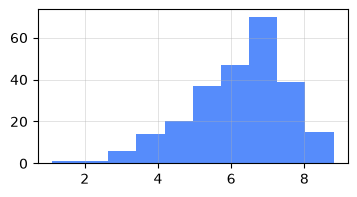

In [14]:
# Plot histogram of rating values
import matplotlib.pyplot as plt
plt.figure(figsize=(4,2))
df['RatingValue'].hist()
# Scale of 1-10.  Popular movies are rated >= 7

# Ask a question about your data


在本演示笔记本中，到目前为止：

1. 您的自定义数据已被映射到向量嵌入空间中。
2. 这些向量嵌入已保存至向量数据库中。
接下来，您可以针对您的自定义数据提出问题！

💡 在LLM词汇中：
> **查询**是用户提问的统称。
> 一个查询可以包含多个独立问题，最多可达1000个不同的问题！

> **问题**通常指单个用户提问。
> 在下面的例子中，用户的提问是：“Milvus Client中的AUTOINDEX是什么？”

> **语义搜索** = 针对整个知识库进行快速搜索，找出与用户查询最接近的TOP_K文档片段。

💡 为了保持一致性，所有嵌入数据和查询都应使用相同的模型。

In [20]:
# Define a sample question about your data
SAMPLE_QUESTION="Innovative sci-fi movies with mind-bending plots"

## Execute a vector search

使用 PyMilvus API 进行 Milvus 搜索。

💡 向量搜索本质上是“语义”搜索。例如，如果你搜索“leaky faucet漏水的水龙头”：

> **传统关键词搜索**——无论是“leaky”还是“faucet”，或者两者都必须与文本匹配，才能返回网页或文档链接。

> **语义搜索**——结果还会包含“drippy”、“taps”等词，因为这些词虽然不同，但含义相同。

In [21]:
# Define a convenience function for searching
def mc_run_search(question,filter_expression,top_k):
    # Embed the question using the same encoder
    query_embeddings=_utils.embed_query(encoder,[question])

    # Run semantic vector search using your query and the vector database
    results=mc.search(
        COLLECTION_NAME,
        data=query_embeddings,
        # search_params=SEARCH_PARAMS
        output_fields=OUTPUT_FIELDS,
        # Milvus can utilize metadata in boolean expressions to filter search
        filter=filter_expression,
        # expr=filter_expression
        limit=top_k,
        consistency_level="Eventually",
    )

    # Assemble retrieved context and context metadata
    # The search result is in the variable `results[0]`, which is type `pymilvus.orm.search.SearchResult`
    METADATA_FIELDS=[f for f in OUTPUT_FIELDS if f != 'chunk']
    formatted_result,contexts,context_metadata=_utils.client_assemble_retrieved_context(
        results,metadata_fields=METADATA_FIELDS,num_shot_answers=TOP_K
    )

    return formatted_result,contexts,context_metadata

## STEP 7. RETRIEVE ANSWERS FROM YOUR DOCUMENTS STORED IN MILVUS OR ZILLIZ

In [31]:
TOP_K=3
# Metadata filtes for CSV dataset
# expression=""
# expression='rating>=6.5'
expression = "array_contains(Genres, 'Sci-Fi') and MovieYear > 2010"
# # infix string match后缀字符串匹配
# expression=expression='&& chunk like "%fiction%"'

# exact array element with prefix or infix match精确匹配前缀或后缀的数组元素
# expression=expression+' && (genres[0] like "Sci-Fi%" || genres[1] like "%Sci-Fi%" || genres[2] == "Sci-Fi")'
# expression=expression + ' && (keywords[0] like "dystop%" || keywords[1] like "%dystop%" || keywords[2] like "%dystop%")'
# # # array contains a value.
# # # https://milvus.io/docs/array_data_type.md#Advanced-filtering
# # expression='array_contains_any(genres, ["Sci-Fi"])'
# # expression='array_contains_any(keywords, ["knife"])'
# # expression='keywords in ["knife"]

print(f"filter: {expression}")

start_time=time.time()
formatted_results,contexts,context_metadata=mc_run_search(SAMPLE_QUESTION,expression,TOP_K)
elapsed_time=time.time()-start_time
print(f"Milvus Client search time for {len(dict_list)} vectors: {elapsed_time} sec")

# Inspect search result
print(f"type: {type(formatted_results)}, count: {len(formatted_results)}")

filter: array_contains(Genres, 'Sci-Fi') and MovieYear > 2010
Milvus Client search time for 807 vectors: 0.22606182098388672 sec
type: <class 'list'>, count: 3


In [32]:
# Dislpay poster link
from IPython.display import Image

# Loop through recommended movies, display poster, print metadata
seen_movies=[]
for i in range(len(contexts)):
    print(f"Retrieved result #{i+1}")
    print(f"distance = {formatted_results[i][0]}")
    # Get the movie_index
    movie_index=context_metadata[i]['id']
    print(f"movie_index: {movie_index}")

    # Don't display the same movie_index twice
    if movie_index in seen_movies:
        pass
    else:
        seen_movies.append(movie_index)

        # Display the first rest of the movie info
        x=Image(url=context_metadata[i]['PosterLink'],width=150,height=200)
        display(x)

        # Print the rest of the movie info
        pprint.pprint(f"chunk: {contexts[i]}")

        # Print metadata except the movie_index and poster link
        for key,value in context_metadata[i].items():
            if (key!='PosterLink')and (key!='id'):
                print(f"{key}: {value}")
        print()

Retrieved result #1
distance = 0.652603030204773
movie_index: 48343


('chunk: truly interesting ideas.  The films also really stretches its budget. '
 'While there are some fantastic practical effects, there are also some really '
 "lousy digital ones.  Devil's Gate it a frustrating movie that frankly should "
 'have been a lot better. The ideas are there, the cast is there, but the '
 "director and screenwriters just can't pull it all together.  My "
 'recommendation, watch The Void instead.')
url: https://www.imdb.com/title/tt4610748/
Name: Devil's Gate
Genres: ['Horror', 'Sci-Fi', 'Thriller']
Actors: ['Amanda Schull', 'Shawn Ashmore', 'Milo Ventimiglia', 'Bridget Regan']
Director: Clay Staub
Keywords: ['abandoned place', 'small town', 'farm', 'trap', 'victim']
RatingValue: 5.099999904632568
MovieYear: 2018

Retrieved result #2
distance = 0.6380444169044495
movie_index: 48347


('chunk: Without digging too much into the story, I kind of enjoyed this as a '
 'sci-fi fan just for the general idea of it. It was still unfocused and all '
 'over the place but I give them credit for sticking with their own ideas.\n'
 '\n'
 "This could've been easily improved with some writing adjustments but it's "
 'fine for what it is. Not exactly a family adventure film and not really a '
 'budget intelligent sci-fi but something in-between.')
url: https://www.imdb.com/title/tt4815122/
Name: Time Trap
Genres: ['Action', 'Adventure', 'Mystery', 'Sci-Fi']
Actors: ['Reiley McClendon', 'Cassidy Gifford', 'Brianne Howey', 'Olivia Draguicevich']
Director: Mark Dennis,Ben Foster
Keywords: ['time travel', 'cave', 'fountain of youth', 'rope', 'sand storm']
RatingValue: 6.300000190734863
MovieYear: 2018

Retrieved result #3
distance = 0.6369026303291321
movie_index: 48336


('chunk: This is an exception if you want to call it that. Then again, you '
 'will only be able to enjoy this movie if you have some patience and if you '
 'are willing to get with the flow of the movie and the pace it sets. Also its '
 'weirdness ... a lot of weirdness going on. Many questions, not so many '
 'answers. Can you dig that? If so, this is really exceptional')
url: https://www.imdb.com/title/tt3986820/
Name: The Endless
Genres: ['Drama', 'Fantasy', 'Horror', 'Mystery', 'Sci-Fi', 'Thriller']
Actors: ['Aaron Moorhead', 'Justin Benson', 'Callie Hernandez', 'Tate Ellington']
Director: Justin Benson,Aaron Moorhead
Keywords: ['brother brother relationship', 'time loop', 'video tape', 'cult', 'moon']
RatingValue: 6.5
MovieYear: 2018



In [ ]:
# # Drop the collection.
# mc.drop_collection(COLLECTION_NAME)
# print(f"Successfully dropped collection: `{COLLECTION_NAME}`")